In [1]:
!export CUDA_VISIBLE_DEVICES=2

In [2]:
import torch
from src.datasets.mos2_sr import BTOSRDataset
from src.models.our_method.swin_cafm import SwinCAFM

MODEL_FP = "__exps__/bto/2025-04-17_15-59-06_bto-8x-no-augs-sr-loss=RMSE-downsample=linear-model=UNet/bto-8x-no-augs-sr-loss=RMSE-downsample=linear-model=UNet_best.pth"

dataset = BTOSRDataset(split="val", upsample_factor=8)
model: SwinCAFM = torch.load(MODEL_FP).cuda()

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/tmp/ipykernel_2246319/3047846083.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `we

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from src.util.material_property_eval import calculate_roughness
from pprint import pprint

EIGHT_X_FP = "data/raw-data/3-12-25/A4 64_Z Height_Backward_012.npy"

# load [64, 64] validation sample
sparse_data = np.load(EIGHT_X_FP)
sparse_data = torch.Tensor(sparse_data)
sparse_sr   = calculate_roughness((sparse_data))

In [4]:
# -> normalize to nn distribution: [0, 1]
X = sparse_data.clone()
X = (X - dataset.topo_maps_min) / (dataset.topo_maps_max - dataset.topo_maps_min)

# X_hat
pred = model(X.cuda().unsqueeze(0))

# -> scale original topology map distribution (nm)f
pred_orig = (
    pred * (dataset.topo_maps_max - dataset.topo_maps_min) + dataset.topo_maps_min
)
pred_orig_np = pred_orig.squeeze(0).detach().cpu().numpy()

# get surface roughness
predicted_sr = calculate_roughness(pred_orig_np)

In [5]:
# get the original, full-resolution topology map
gt = np.load("data/raw-data/3-12-25/A4 512_Z Height_Backward_011.npy")

# get surface roughness
ground_truth_sr = calculate_roughness(gt)

In [6]:
import torch

# 1) Patch and scale parameters
input_patch_size = 48
scale_factor     = 8
gt_patch_size    = input_patch_size * scale_factor  # 384

# 2) Track the best match
min_diff        = float('inf')
best_coords     = None      # will store (i0, j0) in full-res
best_sparse_sr  = None
best_pred_sr    = None
best_gt_sr      = None

H_in, W_in      = sparse_data.shape   # 64, 64
H_full, W_full  = gt.shape            # 512, 512

# 3) Loop over every 48×48 patch in the sparse input
for i in range(0, H_in - input_patch_size + 1):
    for j in range(0, W_in - input_patch_size + 1):
        # --- 3a) Extract sparse patch and compute its roughness ---
        sparse_patch   = sparse_data[i : i + input_patch_size,
                                     j : j + input_patch_size]
        sparse_sr_patch = calculate_roughness(sparse_patch)  

        # --- 3b) Normalize to [0,1] ---
        X_patch = (sparse_patch - dataset.topo_maps_min) \
                / (dataset.topo_maps_max - dataset.topo_maps_min)

        # --- 3c) Run model inference on this patch ---
        with torch.no_grad():
            pred_patch = model(X_patch.unsqueeze(0).cuda())  # →[1,1,384,384]

        # --- 3d) Denormalize back to original topo scale (nm) ---
        pred_orig = (
            pred_patch * (dataset.topo_maps_max - dataset.topo_maps_min)
            + dataset.topo_maps_min
        )
        pred_np = pred_orig.squeeze().cpu().numpy()  # (384,384)

        # --- 3e) Extract the matching gt patch ---
        i0, j0  = i * scale_factor, j * scale_factor
        gt_patch = gt[i0 : i0 + gt_patch_size,
                      j0 : j0 + gt_patch_size]

        # --- 3f) Compute patch‐wise roughnesses ---
        pred_sr = calculate_roughness(pred_np)
        gt_sr   = calculate_roughness(gt_patch)

        # --- 3g) Measure combined absolute difference in roughness metrics ---
        diff = (
            abs(pred_sr["RMS roughness (Sq)"]   - gt_sr["RMS roughness (Sq)"])
          + abs(pred_sr["Mean roughness (Sa)"] - gt_sr["Mean roughness (Sa)"])
        )

        # --- 3h) Update best match if smaller ---
        if diff < min_diff:
            print(f"New best diff: {diff}")
            min_diff        = diff
            best_coords     = (i0, j0)
            best_sparse_sr  = sparse_sr_patch
            best_pred_sr    = pred_sr
            best_gt_sr      = gt_sr


# 4) Report the very best local‐match patch and all three SR values
print(f"Best full‑res patch at top‑left = {best_coords}")
print(f"Minimum Δroughness = {min_diff:.4e}")
print("Sparse patch SR:   ", best_sparse_sr)
print("Predicted patch SR:", best_pred_sr)
print("GT patch SR:       ", best_gt_sr)

New best diff: 0.2846384396952406
New best diff: 0.2793438647887865
New best diff: 0.2726192329313504
New best diff: 0.2689894321577604
Best full‑res patch at top‑left = (8, 48)
Minimum Δroughness = 2.6899e-01
Sparse patch SR:    {'RMS roughness (Sq)': 1.7023665810356192, 'Mean roughness (Sa)': 1.295870633022389}
Predicted patch SR: {'RMS roughness (Sq)': 1.7895197546025088, 'Mean roughness (Sa)': 1.3733838510887608}
GT patch SR:        {'RMS roughness (Sq)': 1.9288363988058133, 'Mean roughness (Sa)': 1.5030566390432167}


# **BTO**: Surface Roughness Figure
---

/tmp/ipykernel_2246319/1442956004.py:18: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  tensors = np.array([sparse_data, pred_orig_np, gt])
/tmp/ipykernel_2246319/1442956004.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  tensors = np.array([sparse_data, pred_orig_np, gt])


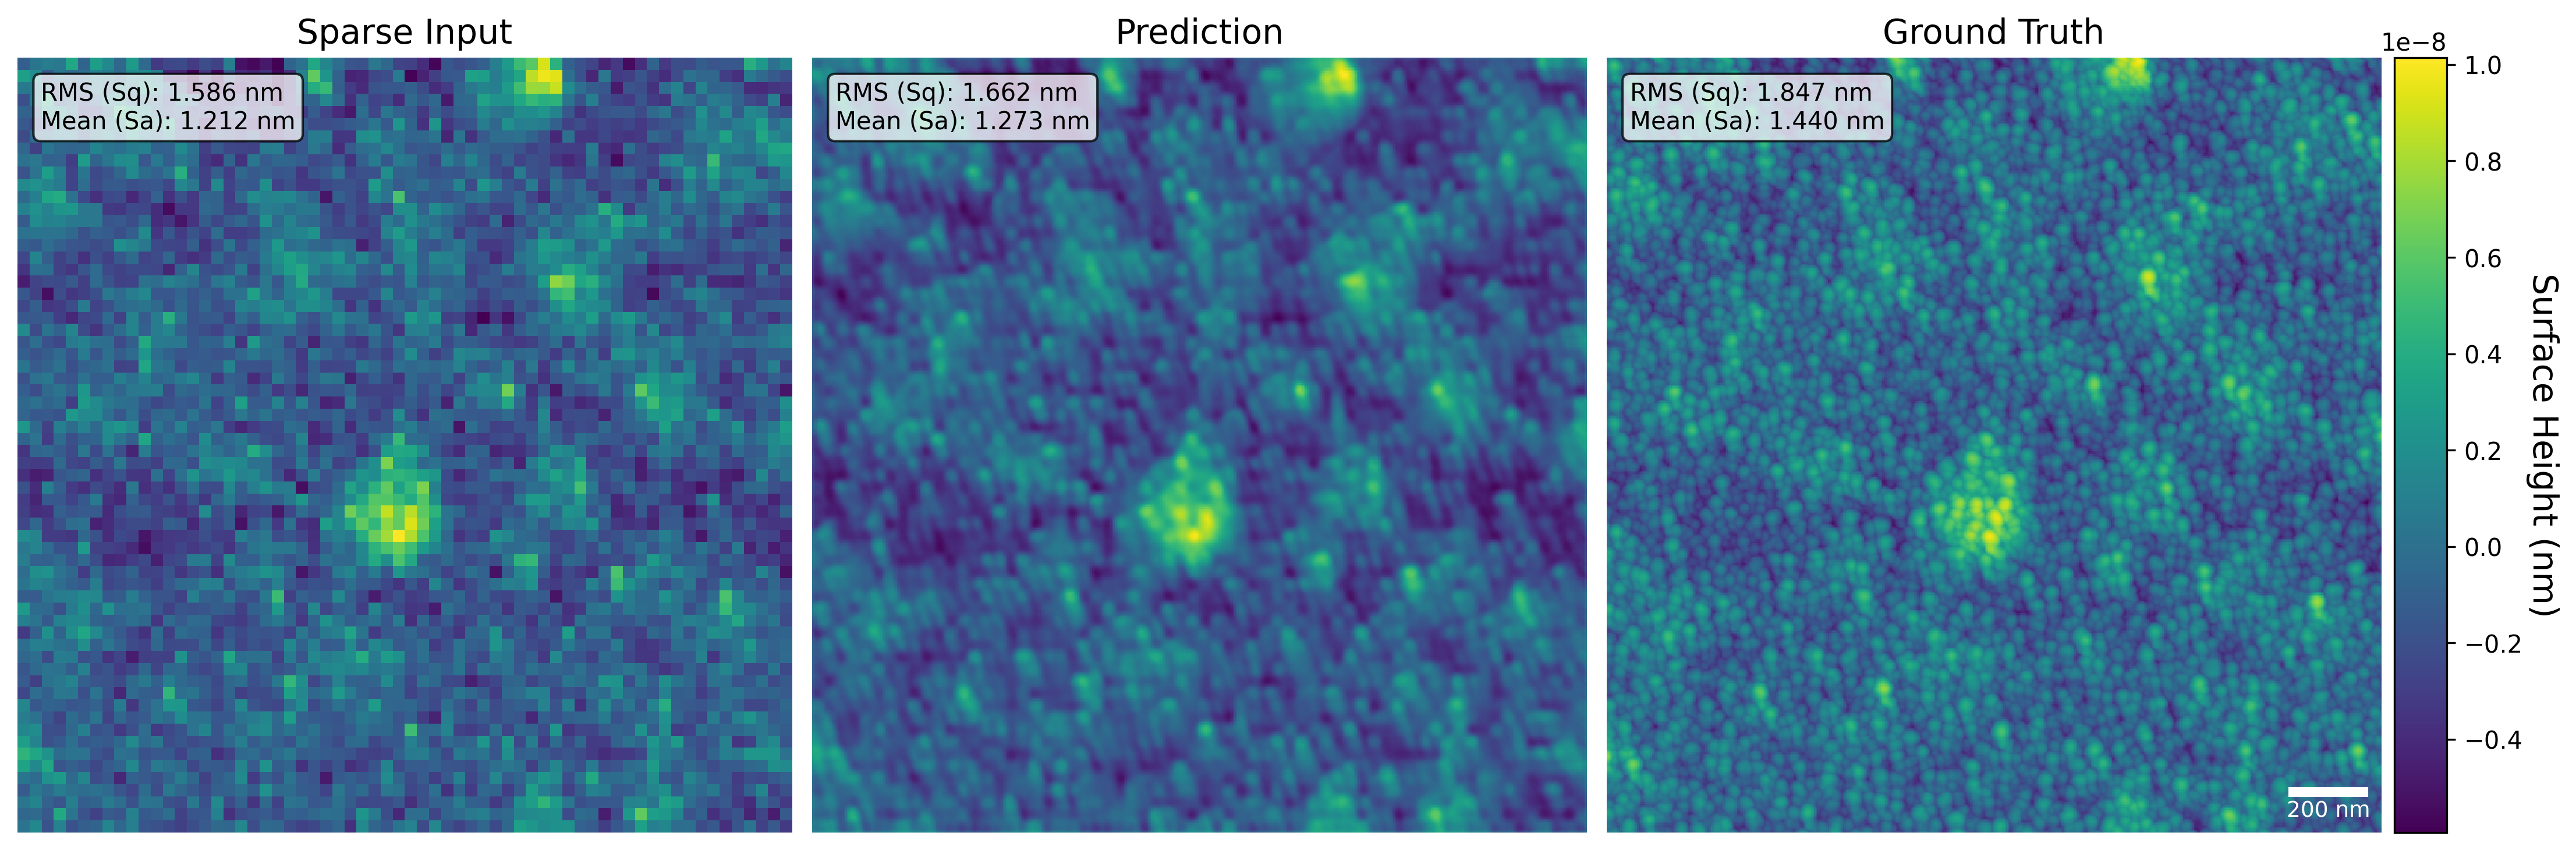

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

fig = plt.figure(figsize=(18, 5.76), dpi=300)
width_ratios = [15, 15, 15, 1]
gs = gridspec.GridSpec(1, 4, width_ratios=width_ratios, wspace=0.01)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])  # ground‑truth axis
cax = fig.add_subplot(gs[0, 3])

image_axes = [ax1, ax2, ax3]
tensors = np.array([sparse_data, pred_orig_np, gt])
titles = ["Sparse Input", "Prediction", "Ground Truth"]

mock_roughness_rms = [
    sparse_sr["RMS roughness (Sq)"],
    predicted_sr["RMS roughness (Sq)"],
    ground_truth_sr["RMS roughness (Sq)"],
]
mock_roughness_mean = [
    sparse_sr["Mean roughness (Sa)"],
    predicted_sr["Mean roughness (Sa)"],
    ground_truth_sr["Mean roughness (Sa)"],
]

im = None
for i, (ax, tensor, title) in enumerate(zip(image_axes, tensors, titles)):
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad(color="lightgrey")
    current_im = ax.imshow(tensor, cmap=cmap, interpolation="nearest")
    if i == 2:  # keep handle for the global colour‑bar
        im = current_im
    ax.set_title(title, fontsize=14)
    ax.axis("off")

    # ---------- roughness text -----------
    rms_str = (
        f"{mock_roughness_rms[i]:.3f}" if not np.isnan(mock_roughness_rms[i]) else "N/A"
    )
    mean_str = (
        f"{mock_roughness_mean[i]:.3f}"
        if not np.isnan(mock_roughness_mean[i])
        else "N/A"
    )
    ax.text(
        0.03,
        0.97,
        f"RMS (Sq): {rms_str} nm\nMean (Sa): {mean_str} nm",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75),
    )

    # ---------- add scale bar ONLY to ground‑truth panel -----------
    if i == 2:
        # ‑‑ choose a physical length you want to show (here 200 nm) and
        #    convert it to *data* units = pixels.
        wanted_nm = 200  # ← change to match your need
        nm_per_pixel = 2000 / 512  # ← calibration from your experiment
        bar_len_pixels = wanted_nm / nm_per_pixel

        scalebar = AnchoredSizeBar(
            ax.transData,
            bar_len_pixels,  # bar length in data units
            f"{wanted_nm} nm",  # text label
            loc="lower right",  # bottom‑right corner
            pad=0.4,  # offset from frame
            color="white",
            frameon=False,
            size_vertical=bar_len_pixels * 0.10,
            fontproperties=fm.FontProperties(size=9),
        )
        ax.add_artist(scalebar)

# ---------- global colour‑bar -----------
if im is not None:
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Surface Height (nm)", rotation=270, labelpad=15, fontsize=14)
else:
    cax.axis("off")

plt.show()

In [8]:
import torch

x = torch.rand(128, 128)
x.pow(2).mean().sqrt()

tensor(0.5742)